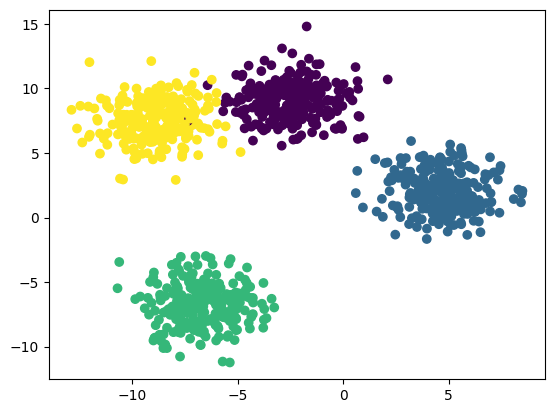

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [2]:
X.shape, y.shape

((1000, 2), (1000,))

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(4, activation="softmax")
])

I0000 00:00:1782165381.944473   21447 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782165381.948574   21447 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782165382.293975   21447 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782165383.724412   21447 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [5]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

E0000 00:00:1782165389.154583   21447 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782165389.155042   21521 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782165389.184071   21447 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2609 - loss: 2.0735 - val_accuracy: 0.3562 - val_loss: 1.5173
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3703 - loss: 1.2988 - val_accuracy: 0.4938 - val_loss: 0.9191
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6422 - loss: 0.7831 - val_accuracy: 0.8375 - val_loss: 0.5533
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8906 - loss: 0.5017 - val_accuracy: 0.9812 - val_loss: 0.3732
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9859 - loss: 0.3448 - val_accuracy: 0.9937 - val_loss: 0.2613
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9875 - loss: 0.2478 - val_accuracy: 0.9937 - val_loss: 0.1923
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9891 - loss: 0.1886 - val_accuracy: 0.9937 - val_loss: 0.1489
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9906 - loss: 0.1500 - val_accuracy: 0.9937 - v

In [7]:
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9950 - loss: 0.0128 
Accuracy: 0.9950000047683716


In [8]:
pred_probs = model.predict(X_test)

print(pred_probs[:5])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[8.8175051e-07 9.9999905e-01 3.7644163e-08 5.3720104e-09]
 [2.8403134e-03 3.9792917e-06 1.3181418e-05 9.9714261e-01]
 [3.5721407e-06 1.3573182e-06 9.9994898e-01 4.6038793e-05]
 [8.8100307e-07 9.9999309e-01 2.8528636e-06 3.2539454e-06]
 [9.9995434e-01 4.5428093e-05 2.3208747e-07 5.7698544e-09]]


In [9]:
import numpy as np

preds = np.argmax(pred_probs, axis=1)

print(preds[:10])

[1 3 2 1 0 3 2 0 2 0]


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


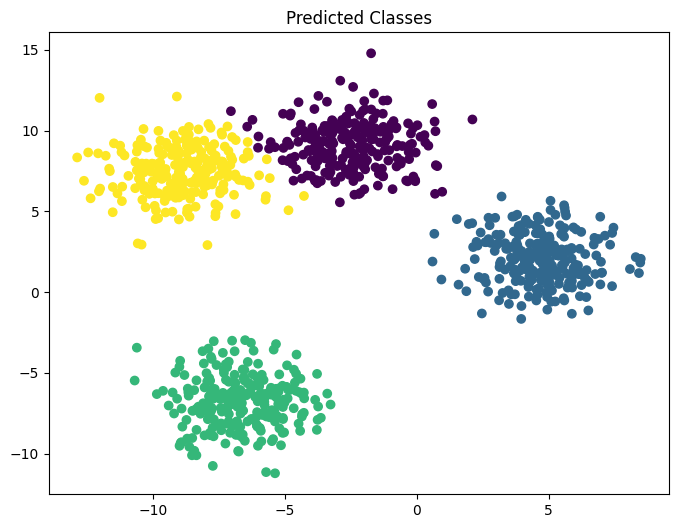

In [13]:
pred_probs = model.predict(X)

pred_classes = pred_probs.argmax(axis=1)

plt.figure(figsize=(8,6))
plt.scatter(
    X[:,0],
    X[:,1],
    c=pred_classes,
    cmap="viridis"
)

plt.title("Predicted Classes")
plt.show()